Logistic Regression Accuracy: 0.8167
Naive Bayes Accuracy: 0.6769
Logistic Regression better.


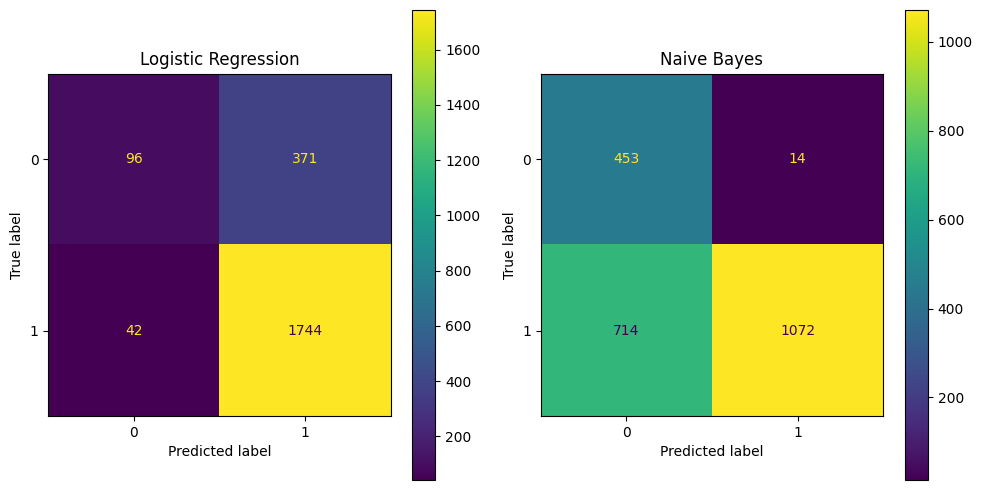

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# load dataset
path = "./../../prj/project/Dataset/anti-malware.csv"
df = pd.read_csv(path)

# drop empty rows and rename columns
df = df.dropna(how='all')
df.columns = range(df.shape[1])
df = df.drop(columns=[0])

# separate target
target_col = df.columns[-1]
df = df[df[target_col].notna()]
Y = df.pop(target_col)
if Y.dtype == 'object':
    Y = Y.map({'No': 0, 'Yes': 1})
X = df

# convert to numeric, impute, and one-hot encode
X = X.apply(pd.to_numeric, errors='coerce')
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

if len(num_cols) > 0:
    X[num_cols] = SimpleImputer(strategy='mean').fit_transform(X[num_cols])
if len(cat_cols) > 0:
    X[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X[cat_cols])
if len(cat_cols) > 0:
    X = pd.get_dummies(X, drop_first=True)
X.columns = X.columns.astype(str)

# scale features
if not X.empty:
    scaler = MinMaxScaler()
    X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# train-test split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# logistic regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train, y_train)
y_pred_log = log_model.predict(x_test)
acc_log = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {acc_log:.4f}")

# naive Bayes
nb_model = GaussianNB()
nb_model.fit(x_train, y_train)
y_pred_nb = nb_model.predict(x_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {acc_nb:.4f}")

# compare performance
if acc_log > acc_nb:
    print("Logistic Regression better.")
elif acc_nb > acc_log:
    print("Naive Bayes better.")
else:
    print("Similar performance.")

#display confusion matrices (optional, if you want to visualize)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp_log.plot(ax=plt.gca())
plt.title("Logistic Regression")

plt.subplot(1, 2, 2)
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb)
disp_nb.plot(ax=plt.gca())
plt.title("Naive Bayes")

plt.tight_layout()
plt.show()
